# Raw data overview

This notebook explores the raw product data .json file to:
- Inspect schema and datatypes
- Measure coverage of key identifiers (EAN, MPN, Brand, Title)
- Check basic distributions (title lengths, price ranges, shops)
- Sample a few records for manual inspection

This part checks for the different datatype values and their occurence

In [1]:
import os
import json
from collections import defaultdict, Counter
from tqdm import tqdm

file_path = "../data/raw/rev2_docs_since_2020_01_01.json"
if not os.path.exists(file_path):
    print(f"File not found: {file_path}")
else:
    print("File found!")

# For storing schema information
field_types = defaultdict(Counter)
total_objects = 0

def get_type(value):
    """Returns a string representation of the value's data type."""
    if value is None:
        return "null"
    elif isinstance(value, bool):
        return "bool"
    elif isinstance(value, int):
        return "int"
    elif isinstance(value, float):
        return "float"
    elif isinstance(value, str):
        return "str"
    elif isinstance(value, list):
        return "list"
    elif isinstance(value, dict):
        return "dict"
    else:
        return "unknown"

with open(file_path, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Processing JSON lines"):
        try:
            obj = json.loads(line.strip())  # Parse each line as a JSON object
            total_objects += 1
            if isinstance(obj, dict):
                for key, value in obj.items():
                    dtype = get_type(value)
                    field_types[key][dtype] += 1
            else:
                print(f"Warning: Element {total_objects} is not a dict. Skipping.")
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON on line {total_objects + 1}: {e}")

# Display results
print(f"\nTotal JSON objects: {total_objects}\n")

File found!


Processing JSON lines: 17983it [00:00, 21468.47it/s]

Processing JSON lines: 6309224it [01:59, 52601.85it/s]


Total JSON objects: 6309224



| **Field**    | **Meaning**                                                                 |
| ------------ | --------------------------------------------------------------------------- |
| `shop_id`    | ID of the shop (i.e., seller) who posted the product (ignore)               |
| `ean`        | European Article Number (GTIN-13 barcode) — a **strong product identifier** |
| `mpnr`       | Manufacturer Part Number — another product ID, **not globally unique**      |
| `price`      | Price of the offer                                                          |
| `product_id` | Internal product ID (probably shop-specific or source-specific)             |
| `name`       | Title or name of the product (what is displayed)                            |
| `cat_id`     | Internal category ID (likely shop-specific or dataset-specific)             |
| `id`         | Unique offer ID in this dataset (this is your primary key)                  |
| `brand`      | The brand of the product (e.g., "Samsung", "Bosch")                         |
| `shop_cat`   | Full category path from the shop (e.g., "Electronics > Phones > Android")   |
| `aid`        | Possibly ad ID / alternate ID used in the crawl (can often be ignored)      |
| `dlv_time`   | Delivery time estimate (e.g., "1-3 Werktage")                               |
| `desc`       | Short description of the product                                            |
| `pzn`        | German pharma product code (if relevant) — useful in healthcare domain      |
| `asin`       | Amazon Standard Identification Number — only present for \~9% of items      |


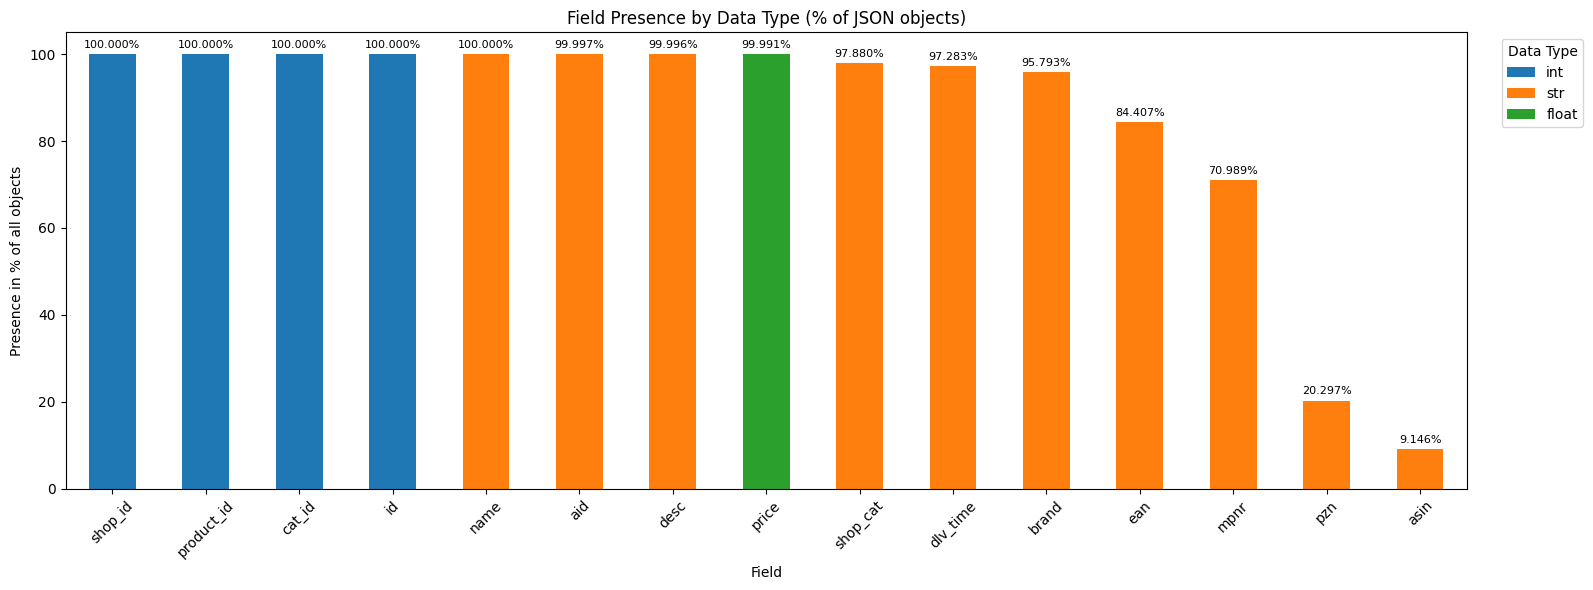

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert to DataFrame (fields as rows, types as columns)
df = pd.DataFrame.from_dict(field_types, orient='index').fillna(0)

# Step 2: Calculate % per type per field
df_percent = (df / total_objects) * 100

# Step 3: Sort by total % (optional, helps readability)
df_percent["__total__"] = df_percent.sum(axis=1)
df_percent = df_percent.sort_values("__total__", ascending=False)
df_percent = df_percent.drop(columns="__total__")

# Step 4: Plot
ax = df_percent.plot(kind="bar", stacked=True, figsize=(16, 6))

# Labels and title
plt.ylabel("Presence in % of all objects")
plt.xlabel("Field")
plt.title("Field Presence by Data Type (% of JSON objects)")
plt.xticks(rotation=45)
plt.ylim(0, 105)
plt.legend(title="Data Type", bbox_to_anchor=(1.02, 1), loc='upper left')

# Step 5: Add total percentage on top of bars
for idx, total in enumerate(df_percent.sum(axis=1)):
    plt.text(idx, total + 1, f"{total:.3f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#

As the data that was received is realtively clean and already matched using the product_id. This product_id will be used as the cluster ID, which is mentioned and manuelly set in **3.1** of the WDC benchmark set.
Here you can see below all the different product IDs there are in how many category groups:

In [3]:
df_json = pd.read_json(file_path, lines=True)
num_prodIDs = df_json['product_id'].nunique()
print(f"Number of unique product IDs: {num_prodIDs}")
num_categories = df_json['cat_id'].nunique()
print(f"Number of unique categories: {num_categories}")

num_cat_list = df_json['shop_cat'].unique().tolist()
print(f"Number of unique shop categories: {len(num_cat_list)}\n")

Number of unique product IDs: 692495
Number of unique categories: 3983
Number of unique shop categories: 194072



As we can't 100% insure that the code is free from non german products as well as having products with super short names we will use the code provided by Bizer and Peeters.

In [4]:
import numpy as np
np.random.seed(42)
import random
random.seed(42)

import math
import string
import regex as re
from gensim.utils import tokenize

import fasttext

from gensim.parsing.preprocessing import lower_to_unicode, preprocess_string, strip_tags, strip_punctuation, strip_multiple_whitespaces, strip_numeric

from tqdm.auto import tqdm
tqdm.pandas()

In [5]:
# class for fasttext language detection
class LanguageIdentification:

    def __init__(self):
        pretrained_lang_model = '../fasttext/lid.176.bin'
        self.model = fasttext.load_model(pretrained_lang_model)

    def predict_lang(self, text):
        predictions = self.model.predict(text, k=5) # returns top 5 matching languages
        return predictions

# function to apply fasttext model and check for less than 5 non-latin chars
def assign_language(text):
    
    processed_text = lower_to_unicode(text)
    CUSTOM_FILTERS = [lambda x: x.lower(), strip_tags, strip_punctuation, strip_multiple_whitespaces, strip_numeric]
    
    processed_text = ' '.join(preprocess_string(processed_text, CUSTOM_FILTERS))
    
    if processed_text.strip() == '':
        return False
    
    result = LANGUAGE.predict_lang(processed_text)
    
    langs = [x.split('__')[-1] for x in result[0]]
    probs = result[1]
    
    if 'de' not in langs:
        return False
    de_idx = langs.index('de')
    if probs[de_idx] == max(probs):
        if len(set(re.findall(r'(\p{IsArabic}|\p{IsArmenian}|\p{IsBengali}|\p{IsBopomofo}|\p{IsBraille}|\p{IsBuhid}|\p{IsCanadian_Aboriginal}|\p{IsCherokee}|\p{IsCyrillic}|\p{IsDevanagari}|\p{IsEthiopic}|\p{IsGeorgian}|\p{IsGreek}|\p{IsGujarati}|\p{IsGurmukhi}|\p{IsHan}|\p{IsHangul}|\p{IsHanunoo}|\p{IsHebrew}|\p{IsHiragana}|\p{IsKannada}|\p{IsKatakana}|\p{IsKhmer}|\p{IsLao}|\p{IsLimbu}|\p{IsMalayalam}|\p{IsMongolian}|\p{IsMyanmar}|\p{IsOgham}|\p{IsOriya}|\p{IsRunic}|\p{IsSinhala}|\p{IsSyriac}|\p{IsTagalog}|\p{IsTagbanwa}|\p{IsTaiLe}|\p{IsTamil}|\p{IsTelugu}|\p{IsThaana}|\p{IsThai}|\p{IsTibetan}|\p{IsYi})', processed_text))) > 4:
            return False
        else:
            return True
    else:
        return False

# function to remove titles with length less than 5 words
def cleanse_by_length(text):
    
    processed_text = lower_to_unicode(text)
    CUSTOM_FILTERS = [lambda x: x.lower(), strip_tags, strip_punctuation, strip_multiple_whitespaces]
    
    processed_text = preprocess_string(processed_text, CUSTOM_FILTERS)
    
    if len(processed_text) < 5:
        return False
    else:
        return True

# function for cluster-based cleansing
def cleanse_by_mainentity_heuristic(cur_cluster):
    if isinstance(cur_cluster, pd.Series):
        cur_cluster = cur_cluster.to_frame().T
    
    cur_cluster = cur_cluster.set_index('id', drop=False)
    cluster_len = len(cur_cluster)
    word_dict = {}
    lengths = []
    to_remove = []

    for i, v in cur_cluster['name_processed'].items():

        words = v
        lengths.append(len(words))

        for word in words:
            if word in word_dict.keys():
                word_dict[word] += 1
            else:
                word_dict[word] = 1

    for i, v in cur_cluster['name_processed'].items():

        count_overlap_main = 0
        
        words = v
        for word in words:
            if word_dict[word] >= math.ceil(cluster_len / 3):
                count_overlap_main += 1
        if count_overlap_main <= math.floor((sum(lengths)/len(lengths)) / 4):
            to_remove.append(i)

    return to_remove
    
LANGUAGE = LanguageIdentification()

In [10]:
corpus = df_json.copy()
corpus['title_temp'] = corpus['name'].fillna('')
corpus['description_temp'] = corpus['desc'].fillna('')
corpus['title+desc'] = corpus['title_temp'] + ' ' + corpus['description_temp']
corpus['is_de'] = corpus['title+desc'].progress_apply(assign_language)

corpus.to_pickle('../data/working/preprocessed_rev2_docs_since_2020_01_01_only_de_strict.pkl.gz')

  0%|          | 0/6309224 [00:00<?, ?it/s]

In [11]:
corpus = corpus[corpus['is_de'] == True]
corpus['description_temp'] = corpus['desc']
corpus['brand_temp'] = corpus['brand']
corpus = corpus.dropna(subset=['name'])
corpus = corpus.fillna({'description_temp':'', 'brand_temp':''})

corpus['name+description+brand'] = corpus['name'] + ' ' + corpus['description_temp'] + ' ' + corpus['brand_temp']
corpus['name+description+brand'] = corpus['name+description+brand'].apply(lambda x: ' '.join(x.lower().split()))
corpus = corpus.drop_duplicates(subset=['name+description+brand'])

corpus.to_pickle('../data/working/dedup_preprocessed_rev2_docs_since_2020_01_01_only_de_strict.pkl.gz')

In [12]:
corpus['has_long_name'] = corpus['name'].progress_apply(cleanse_by_length)
corpus = corpus[corpus['has_long_name'] == True]

corpus.to_pickle('../data/working/dedup_preprocessed_rev2_docs_since_2020_01_01_only_de_strict_only_long_name.pkl.gz')

  0%|          | 0/3308479 [00:00<?, ?it/s]

Not needed as our Data is really clean

In [13]:
"""
# Can be removed
import multiprocessing as mp
from tqdm.contrib.concurrent import process_map
import pandas as pd

corpus = pd.read_pickle('../data/working/dedup_preprocessed_rev2_docs_since_2020_01_01_only_de_strict_only_long_name.pkl.gz')


corpus['is_mainentity'] = True
    
corpus_selection = corpus[['name', 'product_id', 'id']].copy()
counts = corpus_selection['product_id'].value_counts()
counts = counts[counts > 1]
corpus_selection = corpus_selection[corpus_selection['product_id'].isin(counts.index)]

clusters = list(set(corpus_selection['product_id']))
to_remove = []
CUSTOM_FILTERS = [lambda x: x.lower(), strip_tags, strip_punctuation, strip_multiple_whitespaces]

corpus_selection['name_processed'] = corpus_selection['name'].apply(lower_to_unicode)
corpus_selection['name_processed'] = corpus_selection['name_processed'].apply(preprocess_string, args=(CUSTOM_FILTERS,))
corpus_selection['name_processed'] = corpus_selection['name_processed'].apply(set)
corpus_selection = corpus_selection[['name_processed', 'product_id', 'id']]

corpus_selection = corpus_selection.set_index('product_id', drop=False)
corpus_selection = corpus_selection.sort_index()

# As the corpus_selection = corpus_selection.set_index('product_id', drop=False) line above messes up the indexing, we need to re-select the clusters data
# clusters_data = [corpus_selection.loc[cluster] for cluster in tqdm(clusters)]
clusters_data = []

for cluster in tqdm(clusters):
    data = corpus_selection.loc[cluster]
    if isinstance(data, pd.Series):
        data = data.to_frame().T
    clusters_data.append(data)

# Could not do multiprocessing on Mac M1, so using single core for now
#batch = 10000
#n_workers = 20
#results = process_map(cleanse_by_mainentity_heuristic,clusters_data, max_workers=n_workers, chunksize=batch)
results = []
for cluster_data in tqdm(clusters_data):
    results.append(cleanse_by_mainentity_heuristic(cluster_data))
    
to_remove = set()

for result in tqdm(results):
    to_remove.update(result)
    
corpus.loc[corpus['id'].isin(to_remove), 'is_mainentity'] = False

corpus = corpus[corpus['is_mainentity'] == True]
corpus.to_pickle('../data/working/dedup_preprocessed_rev2_docs_since_2020_01_01_only_de_strict_only_long_title_only_mainentity.pkl.gz')"""

"\n# Can be removed\nimport multiprocessing as mp\nfrom tqdm.contrib.concurrent import process_map\nimport pandas as pd\n\ncorpus = pd.read_pickle('../data/working/dedup_preprocessed_rev2_docs_since_2020_01_01_only_de_strict_only_long_name.pkl.gz')\n\n\ncorpus['is_mainentity'] = True\n    \ncorpus_selection = corpus[['name', 'product_id', 'id']].copy()\ncounts = corpus_selection['product_id'].value_counts()\ncounts = counts[counts > 1]\ncorpus_selection = corpus_selection[corpus_selection['product_id'].isin(counts.index)]\n\nclusters = list(set(corpus_selection['product_id']))\nto_remove = []\nCUSTOM_FILTERS = [lambda x: x.lower(), strip_tags, strip_punctuation, strip_multiple_whitespaces]\n\ncorpus_selection['name_processed'] = corpus_selection['name'].apply(lower_to_unicode)\ncorpus_selection['name_processed'] = corpus_selection['name_processed'].apply(preprocess_string, args=(CUSTOM_FILTERS,))\ncorpus_selection['name_processed'] = corpus_selection['name_processed'].apply(set)\ncorpu

Now let's see how many items were removed in the cleaning:

In [14]:
#Items Before seen from above:
# Total JSON objects: 6309224

corpus1 = pd.read_pickle("../data/working/preprocessed_rev2_docs_since_2020_01_01_only_de_strict.pkl.gz")
corpus2 = pd.read_pickle("../data/working/dedup_preprocessed_rev2_docs_since_2020_01_01_only_de_strict.pkl.gz")
corpus3 = pd.read_pickle('../data/working/dedup_preprocessed_rev2_docs_since_2020_01_01_only_de_strict_only_long_name.pkl.gz')

print("Number of rows first cleaning:", len(corpus1))
print("Number of rows second cleaning:", len(corpus2))
print("Number of rows third cleaning:", len(corpus3))


Number of rows first cleaning: 6309224
Number of rows second cleaning: 3308479
Number of rows third cleaning: 3030931


Sanity Check noch TODO zum notieren


Grafik was ich eigentlich alles drin hab - Kategorien - out of distribution - zeigen dass die nicht spezifisch angebot
- breiter funktionieren
nach amazon kategorien richten

In [1]:
import pandas as pd
corpus = pd.read_pickle('../data/working/dedup_preprocessed_rev2_docs_since_2020_01_01_only_de_strict_only_long_name.pkl.gz')
print("Columns:", corpus.columns.tolist())

Columns: ['shop_id', 'ean', 'mpnr', 'price', 'product_id', 'name', 'cat_id', 'id', 'brand', 'shop_cat', 'aid', 'dlv_time', 'desc', 'pzn', 'asin', 'title_temp', 'description_temp', 'title+desc', 'is_de', 'brand_temp', 'name+description+brand', 'has_long_name']
